#Sofia Moscoso Ortiz
##10150686340


## Problemas

**1** Realice el problema del borracho visto en clase en dos dimensiomnes; es decir, que el desplazamiento se realice tanto en `x` como en `y`, y grafique su desplazamiento. Recuerde que el paso se puede dar en `x` o en `y` de forma aleatoria y grafique



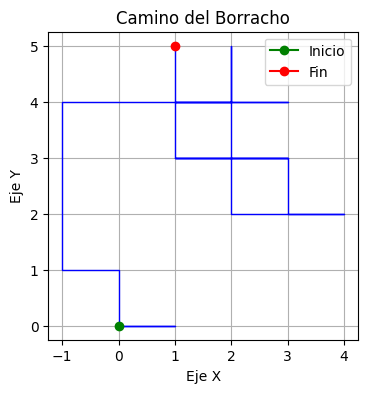

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
x= [0]
y= [0]
posicion=np.array([0,0])
for i in range(30):
  direccion = random.choice([(0, 1), (0, -1), (1, 0), (-1, 0)])
  posicion = direccion + posicion

  x.append(posicion[0])
  y.append(posicion[1])

plt.figure(figsize=(4, 4))
plt.plot(x, y, lw=1, color='blue')
plt.plot(x[0], y[0], marker='o', color='green', label='Inicio')
plt.plot(x[-1], y[-1], marker='o', color='red', label='Fin')
plt.title("Camino del Borracho")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)


**2** Ahora realice nuevamente el problema del borracho pero esta vez sin restricciones en la dirrección. Considere un ángulo asociado y grafique el desplazamiento.


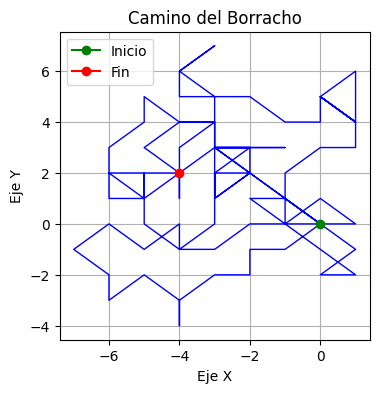

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
x= [0]
y= [0]

posicion=np.array([0,0])
for i in range(100):
  direccion = random.choice([(0, 1), (0, -1), (1, 0), (-1, 0),(1,1),(-1,1),(1,-1),(-1,-1)])
  posicion = direccion + posicion

  x.append(posicion[0])
  y.append(posicion[1])

plt.figure(figsize=(4, 4))
plt.plot(x, y, lw=1, color='blue')
plt.plot(x[0], y[0], marker='o', color='green', label='Inicio')
plt.plot(x[-1], y[-1], marker='o', color='red', label='Fin')
plt.title("Camino del Borracho")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)


**3** Cree un función que, de forma aleatoria, calcule la posición final del borracho en cualquiera de los tres casos (solo x, o solo y, ó x,y). Ahora con esta función cree un diccionario donde guarde: (el grado de libertad, la posición final)

In [ ]:
def posicionn(iteraciones):
  posicion=np.array([0,0])
  posiciones = [[0,0]]

  for i in range(iteraciones):
    direccion = random.choice([(0, 1), (0, -1), (1, 0), (-1, 0),(1,1),(-1,1),(1,-1),(-1,-1)])
    posicion = direccion + posicion
    posiciones.append(list(posicion))

  keys = np.arange(iteraciones+1)
  dicc_pos = dict.fromkeys(keys)
  for i in dicc_pos:
    dicc_pos[i] = posiciones[i]
  return dicc_pos
posicionn(31)


**4** Genere 10.000 puntos en el diccionario anterior, carguelo con pandas e incluya una columna donde muestre la distancia al punto final. Añada otra columna que sea categórica (SI,NO), refiriéndose en cada entrada: si el borracho alcanzo a llegar a la posicion deseada o no. Finalmente haga un análisis de cual es el porcentaje de acierto en cada caso.


In [ ]:
import pandas as pd
i = 10000
pd_borracho = pd.DataFrame(posicionn(i))
pd_borracho = pd_borracho.transpose()
pd_borracho.columns = [ "Pos en x" , "Pos en y"]
pd_borracho["distancia"] = ((((pd_borracho["Pos en x"][i])-(pd_borracho["Pos en x"]))**2)+(((pd_borracho["Pos en y"][i])-(pd_borracho["Pos en y"]))**2))**1/2
# Definiendo como posicion deseada (10,10)
pd_borracho["llegada"] = "NO"
pd_borracho



**5**. Realice un análisis similar al visto en clase (para la función seno) por error de método para la serie de $e^x$. ¿En cuál de las dos series (seno o euler) crece más rápido el error?


In [ ]:
#Ángulos y valores de x para comparar
theta=np.linspace(-1*np.pi/2,np.pi/2,1000)
x=np.linspace(0,500,1000)

#Serie función seno aproximada y seno real
def serie_seno(x,O):
  seno=0
  for n in range(0,O+1):
    seno+= (((-1)**n)*(x**(2*n+1)))/(mt.factorial(2*n+1))
  return seno

#Función seno vectorizada
func_vect_seno=np.vectorize(serie_seno,excluded=['O'])
sen2=func_vect_seno(theta,2)
sen3=func_vect_seno(theta,3)
sen4=func_vect_seno(theta,4)
sen5=func_vect_seno(theta,5)

def seno(x):
  seno_real=np.sin(x)
  return seno_real

seno_theta=seno(theta)


#Serie función exponencial
def serie_exp(x,O):
  exp=0
  for n in range(0,O+1):
    exp+=((x**n)/(mt.factorial(n)))
  return exp

#Función Exponencial vectorizada
func_vect_exp=np.vectorize(serie_exp,excluded=['O'])
exp2=func_vect_seno(x,2)
exp3=func_vect_seno(x,3)
exp4=func_vect_seno(x,4)
exp5=func_vect_seno(x,5)

def Euler(x):
  exp_real=np.exp(x)
  return exp_real

e_x=Euler(x)


**6**. Programe una clase que encuentre en un tiempo dado la posición en x o en y en un movimiento en tiro parabólico, dadas las demás condiciones. Luego genere una lista de 100 tiempos y grafíquela con matplotlib.

Ingrese el ángulo del lanzamiento: 45
Ingrese la velocidad inicial: 12


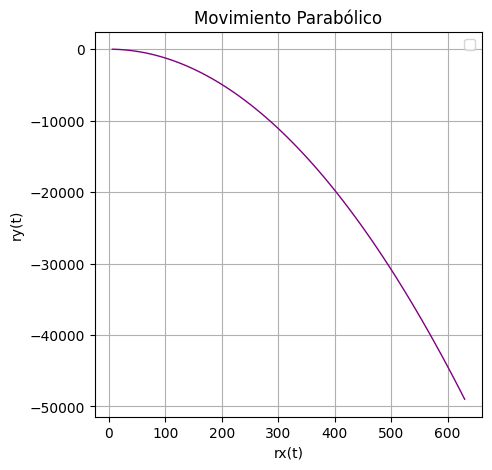

In [ ]:
import matplotlib.pyplot as plt
import math as mt
import numpy as np

class MovimientoParabolico:
    def __init__(self, angulo, velocidad_inicial):
        self.angulo = angulo
        self.velocidad_inicial = velocidad_inicial
        self.g = 9.8
        self.tiempo = np.arange(1, 101)
        self.calcular_posiciones()

    def calcular_posiciones(self):
        self.rx = self.velocidad_inicial * (mt.cos(self.angulo)) * self.tiempo
        self.ry = (self.velocidad_inicial * (mt.sin(self.angulo))) - ((1/2) * self.g * (self.tiempo**2))

    def graficar(self):
        plt.figure(figsize=(5, 5))
        plt.plot(self.rx, self.ry, "-", lw=1, color="purple")
        plt.title("Movimiento Parabólico")
        plt.xlabel("rx(t)")
        plt.ylabel("ry(t)")
        plt.legend()
        plt.grid(True)
        plt.show()

angulo = int(input("Ingrese el ángulo del lanzamiento: "))
velocidad_0 = int(input("Ingrese la velocidad inicial: "))

movimiento = MovimientoParabolico(angulo, velocidad_0)
movimiento.graficar()


In [ ]:
1